In [8]:
# pip install pytorch_tabnet

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [10]:
# Initial pull
car_df = pd.read_csv('merged_output.csv')

In [11]:
# Remove rows where 'source' is 'UCI'
car_df_2 = car_df[car_df['source'] != 'UCI']

# Drop the 'source' column
car = car_df_2.drop(columns=['source'])

# Drop missing values
car = car.dropna()

# Take a random sample of 1000 rows
car_small = car.sample(n=273456, random_state=42)

In [12]:
car_small.head()

,make,model,year,engine_size,mileage,fuel_type,transmission,price
269223,Volkswagen,Caddy Maxi Life,2012.0,1.6,60178.0,Diesel,Manual,9995.000000
8838,Honda,Model D,2000.0,2.1,173468.0,Petrol,Manual,14639.483156
265070,Volkswagen,Touran,2003.0,1.9,162120.0,Diesel,Manual,990.000000
179359,Audi,Q7,2015.0,3.0,34752.0,Diesel,Automatic,29289.000000
160661,Renault,Twingo,2009.0,1.6,99773.0,Petrol,Manual,2790.000000


In [13]:
print(car.shape)
print(car_small.shape)

(273456, 8)
(273456, 8)


In [14]:
# Label encode categorical columns
cat_cols = ['make', 'model', 'fuel_type', 'transmission']
num_cols = ['year', 'engine_size', 'mileage']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    car_small[col] = le.fit_transform(car_small[col])
    label_encoders[col] = le

# Features and target
X = car_small.drop(columns=['price'])
y = car_small['price']

In [15]:
# Get categorical feature indices and dimensions for TabNet
cat_idxs = [X.columns.get_loc(col) for col in cat_cols]
cat_dims = [car_small[col].nunique() for col in cat_cols]

In [16]:
# Train-Test-Split with 30% test, 70% train
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
# Split temp set into validation and test sets
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [17]:
# Scale numeric features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid[num_cols] = scaler.transform(X_valid[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [18]:
# TabNetRegressor model initialization
model = TabNetRegressor(
    n_d=32,
    n_a=32,
    n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1
)

/opt/anaconda3/lib/python3.13/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


In [19]:
# Convert train/val/test sets to numpy arrays
X_train = X_train.values
X_valid = X_valid.values
X_test = X_test.values

# Reshape targets
y_train = y_train.values.reshape(-1,1)
y_valid = y_valid.values.reshape(-1,1)
y_test = y_test.values.reshape(-1,1)

In [22]:
# Training the model
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=['mae'],
    max_epochs=40,
    patience=15,
    batch_size=128
)

# Hyperparameters:
# max_epochs = 40
# patience = 15
# batch_size = 128

epoch 0  | loss: 290520747.02274| val_0_mae: 5260.69806|  0:00:13s
epoch 1  | loss: 146419160.39866| val_0_mae: 4230.57238|  0:00:25s
epoch 2  | loss: 123168452.22943| val_0_mae: 4142.63036|  0:00:38s
epoch 3  | loss: 110125264.0| val_0_mae: 3925.21624|  0:00:50s
epoch 4  | loss: 102375054.34381| val_0_mae: 3098.03332|  0:01:03s
epoch 5  | loss: 95794152.83211| val_0_mae: 3592.72263|  0:01:17s
epoch 6  | loss: 95009468.72575| val_0_mae: 4523.05629|  0:01:30s
epoch 7  | loss: 91628227.28696| val_0_mae: 4186.64587|  0:01:42s
epoch 8  | loss: 88340183.56923| val_0_mae: 4856.91015|  0:01:55s
epoch 9  | loss: 86443519.47676| val_0_mae: 4838.15268|  0:02:08s
epoch 10 | loss: 86902505.0403| val_0_mae: 4114.34062|  0:02:21s
epoch 11 | loss: 84193014.26589| val_0_mae: 5140.00536|  0:02:34s
epoch 12 | loss: 83400090.04281| val_0_mae: 1997.95442|  0:02:47s
epoch 13 | loss: 81112793.26622| val_0_mae: 3717.03342|  0:02:59s
epoch 14 | loss: 79909161.41756| val_0_mae: 4244.73349|  0:03:12s
epoch 15 |

/opt/anaconda3/lib/python3.13/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


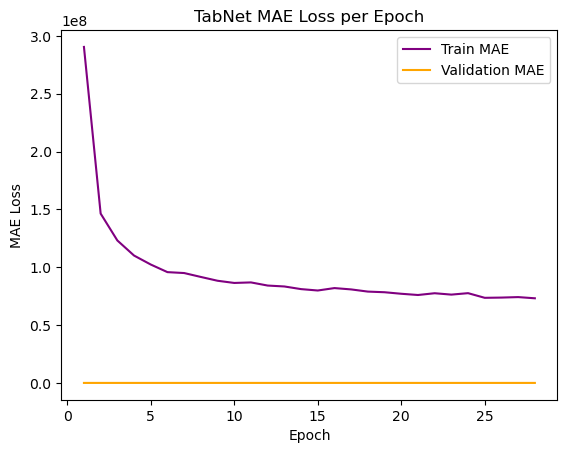

In [28]:
# Plot both training and validation MAE per epoch for TabNet
history = model.history
train_loss = np.array(history['loss']).squeeze()
val_loss = np.array(history['val_0_mae']).squeeze()
epochs = np.arange(1, len(train_loss) + 1)

plt.plot(epochs, train_loss, color='purple', label='Train MAE')
plt.plot(epochs, val_loss, color='orange', label='Validation MAE')
plt.title('TabNet MAE Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MAE Loss')
plt.legend()
plt.show()

In [ ]:
print(len(X_train))
print(len(X_test))

191419
41019


In [ ]:
# Predict target using trained model
preds = model.predict(X_test)
print("Predictions:",len(preds), "\n")
print(preds[:5])

Predictions: 41019 

[[ 8907.477 ]
 [ 4035.6016]
 [22214.95  ]
 [11338.829 ]
 [ 5005.0034]]


In [ ]:
# F1, accuracy, precision, and recall are better suited for classification
# So we will assess performance with 4 regression metrics
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

MAE: 2167.682, MSE: 2420632254.321, RMSE: 49199.921, R2: 0.176
